# Setup phase

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("iris") # hoac: from sklearn.datasets

print(df.head())
print(df.shape)
print(df.dtypes)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


# Phần 1 - Thống kê mô tả & đặc trưng

## 1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [3]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


5 dòng, 5 cột, các cột theo thứ tự là sepal_length(kiểu dữ liệu float), sepal_width(kiểu dữ liệu float), petal_length(kiểu dữ liệu float), petal_width(kiểu dữ liệu float) và species(kiểu dữ liệu string)

## 2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR

In [4]:
df.mean(numeric_only=True)

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [5]:
df.median(numeric_only=True)

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [6]:
df.mode(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
0,5.0,3.0,1.4,0.2
1,NaN,NaN,1.5,NaN


In [7]:
df.var(numeric_only=True)

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [8]:
df.std(numeric_only=True)

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [9]:
df.min(numeric_only=True)

sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

In [10]:
df.max(numeric_only=True)

sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

In [11]:
df.quantile([0.25,0.75], numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
0.25,5.1,2.8,1.6,0.3
0.75,6.4,3.3,5.1,1.8


In [12]:
df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)

sepal_length    1.3
sepal_width     0.5
petal_length    3.5
petal_width     1.5
dtype: float64

In [13]:
df.groupby('species').mean(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [14]:
df.groupby('species').std(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


Nhận xét  : Thông qua quan sát về độ lệch chuẩn của từng biến, ta nhận thấy nhóm loài setosa có sự khác biệt ít nhất, trong khi đó, nhóm loài virginica lại có sự khác biệt rõ nhất. Em không lấy trung bình vì có thể sẽ có outliers làm sai lệch dữ liệu

# Phần 2 - Phân phối xác suất

## 1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

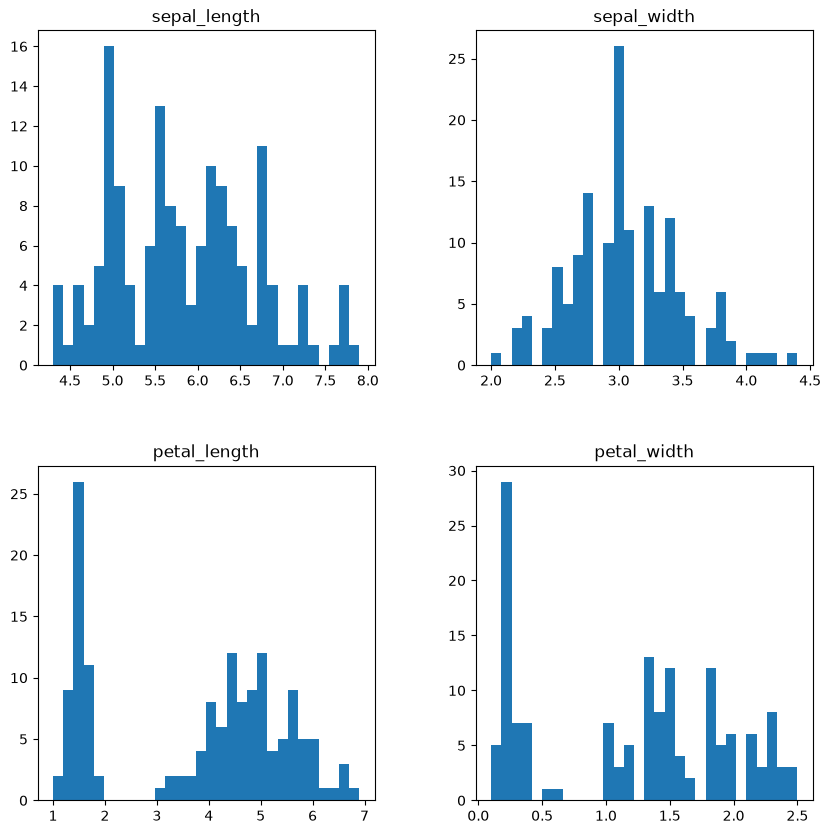

In [15]:
hist = df.hist(figsize=(10, 10), bins=30, grid=False)


<Axes: ylabel='Density'>

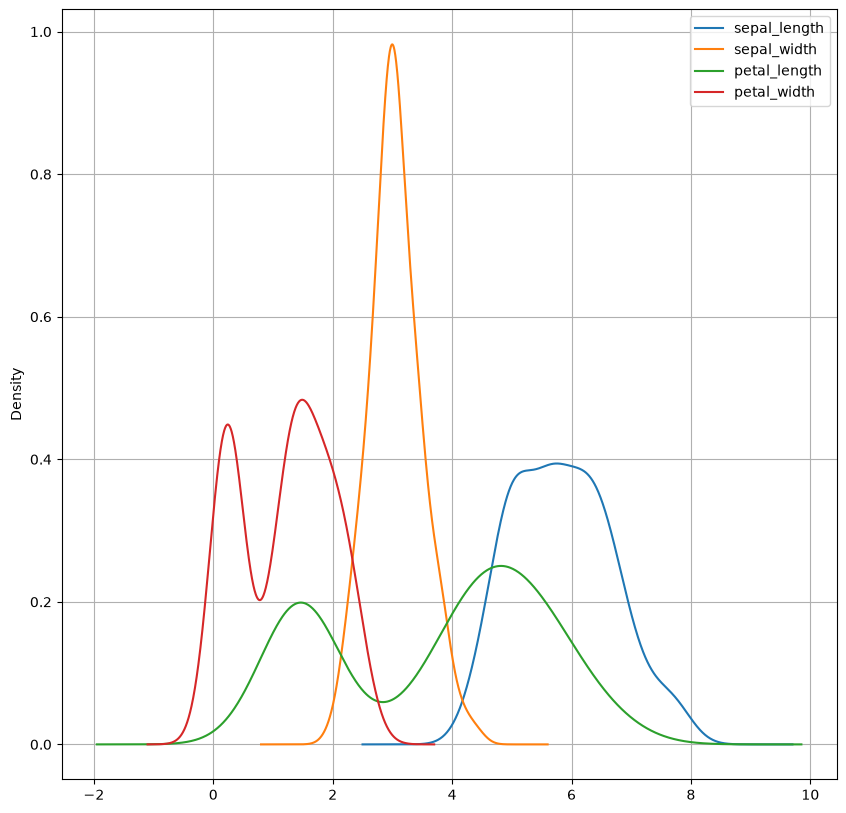

In [16]:
df.plot.kde(figsize=(10, 10), grid=True)

Nhận xét hình dạng phân phối:
- sepal_length: đồ thị có xu hướng lệch phải, có một đỉnh nhưng không có hình dạng của phân phối chuẩn

- sepal_width: đồ thị lệch phải một chút, nhìn chung là phân phối chuẩn

- petal_length: đồ thị có nhiều đỉnh, không phải phân phối chuẩn

- petal_width: đồ thị có nhiều đỉnh, không phải phân phối chuẩn 

## 2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài

array([[<Axes: title={'center': 'petal_length'}, xlabel='[species]'>,
        <Axes: title={'center': 'petal_width'}, xlabel='[species]'>],
       [<Axes: title={'center': 'sepal_length'}, xlabel='[species]'>,
        <Axes: title={'center': 'sepal_width'}, xlabel='[species]'>]],
      dtype=object)

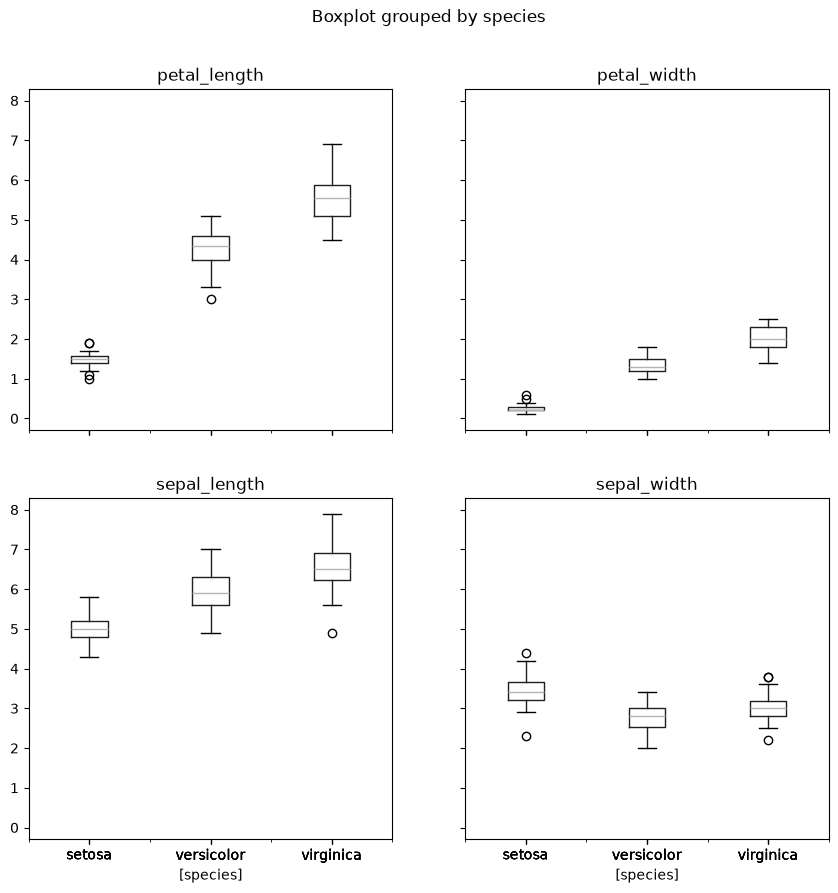

In [17]:
df.boxplot(by='species', figsize=(10, 10), grid=False)


Nhận xét:
- petal_length: ở loài setosa thì có nhiều outliers, độ phân tán thấp; versicolor thì lệch trái và có outliers ở chặn dưới; còn virginica thì không có outliers đồng thời lệch trái một ít, độ phân tán cao

- petal_width: ở loài setosa thì có nhiều outliers chặn trên , độ phân tán thấp; versicolor thì lệch trái và không có outliers với độ phân tán thấp; còn virginica thì cũng không có outliers và cũng có độ phân tán thấp.

- sepal_length: ở loài setosa và versicolor thì không có outlier, ở loài virginica thì có outliers và lệch phải, so với setosa thì đồ thị dạng chuẩn.

- sepal_width: ở loài setosa và virginica thì có outlier ở 2 đầu mút, versicolor thì không có outlier và đồ thị xấp xỉ một đồ thị phân tán chuẩn.

-

## 3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp

### Mô phỏng

In [18]:
mean = df['sepal_length'].mean()
std = df['sepal_length'].std()
normal = np.random.normal(mean,std,len(df['sepal_length']))

### Vẽ histogram

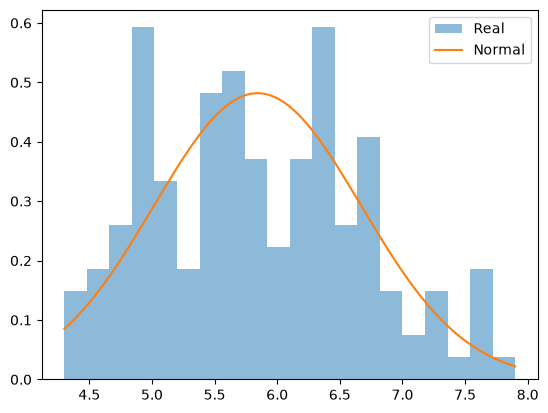

In [19]:
plt.hist(df['sepal_length'], bins=20, density=True,
         alpha=0.5, label="Real")


x = np.linspace(df['sepal_length'].min(),df['sepal_length'].max(),  200)

pdf = np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

plt.plot(x, pdf, label = 'Normal')

plt.legend()
plt.show()

Nhận xét : Đồ thị cũng khá khớp với một đồ thị phân phối chuẩn, tuy nhiên có 2 đỉnh của đồ thị gốc làm sai lệch sự tương khớp giữa hai đồ thị, và một vài giá trị ở upper bound khiến cho đồ thị cũng không quá khớp so với đồ thị chuẩn.

# Phần 3 - Phân tích đa biến & tương quan 

## 1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số

In [20]:
df.cov(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [21]:
corr = df.corr(numeric_only=True)
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


## 2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

<Axes: >

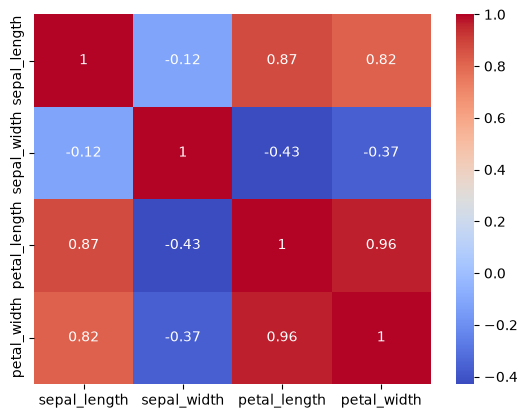

In [22]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

Cặp biến tương quan mạnh nhất là petal_length và petal_width (0.96)

Em nhận thấy dấu hiệu đa cộng tuyến giữa petal_length và petal_width (0.96 ~ 1 : tương quan dương rất mạnh), đồng thời sepal_length và petal_length cũng có dấu hiệu của đa cộng tuyến (0.87 cũng là con số tương quan dương rất cao)

## 3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến

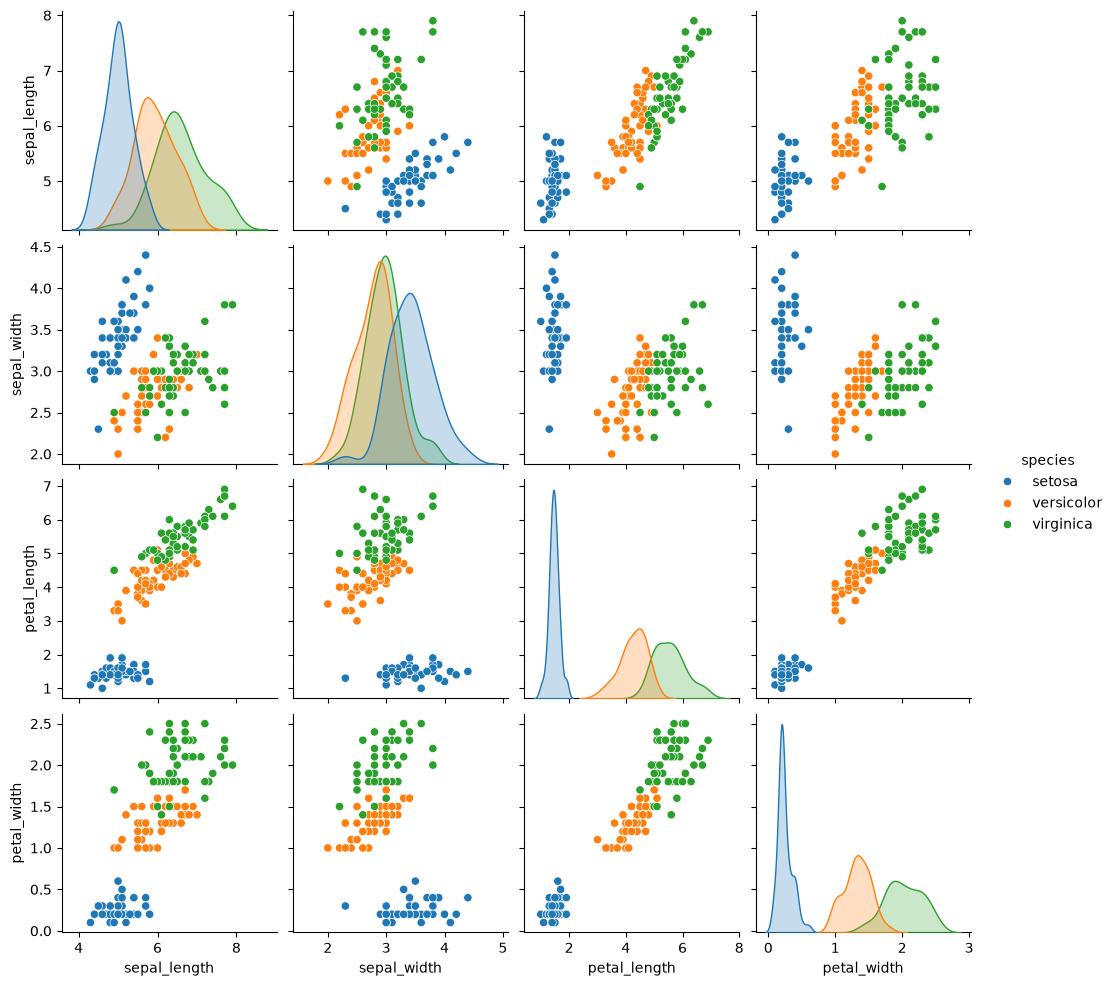

In [23]:
sns.pairplot(df, hue="species")

Nhận xét: 
Đối với quan hệ các biến
- sepal_length và sepal_width: khá phân tán, tương quan không rõ rệt, setosa có sự phân cụm rõ ràng hơn so với phần còn lại, phần còn lại chồng lấn lộn xộn, khó phân biệt

- sepal_length và petal_length: nhận thấy tương quan dương rõ rệt,setosa có sự phân cụm rõ ràng hơn so với phần còn lại, nhưng nhìn nhưng phần còn lại không chồng lấn quá nhiều

- sepal_length và petal_width: nhận thấy tương quan dương khá rõ, setosa có sự phân cụm rõ ràng hơn so với phần còn lại, nhưng nhìn nhưng phần còn lại không chồng lấn quá nhiều

- sepal_width và petal_length: xu hướng tương quan âm nhẹ, đồng thời, setosa tách biệt rõ ràng, phần còn lại tuy gần nhau nhưng phân biệt được. Có vẻ như có một giá trị outlier trong loài setosa. 

- sepal_width và petal_width: xu hướng tương quan âm nhẹ, đồng thời, setosa tách biệt rõ ràng, phần còn lại tuy gần nhau nhưng phân biệt được. Có outlier đối với setosa.

- petal_length và petal_width: xu hướng tương quan dương mạnh, phân tán rõ, tất cả các cụm tách rời nhau cụ thể.

Đối với từng cụm:
- sepal_length: các cụm khá chồng lấn khi tiến gần đến mean của mẫu số liệu chung.

- sepal_width: các cụm chồng lấn rõ rệt, khó phân biệt được.

- petal_length: setosa tách rời, còn 2 cụm còn lại tuy có chồng lấn nhưng nhìn chung vẫn chấp nhận được 

- petal_width:setosa tách rời, còn 2 cụm còn lại tuy có chồng lấn nhưng nhìn chung vẫn chấp nhận được 

# 4. Xác suất & Định lý Bayes

## 1. Viết code tính xác suất hậu nghiệm P (B |+) bằng định lý Bayes và in kết quả

In [24]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05
P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos
print(round(P_B_given_pos , 4))  



0.1667


## 2. Khảo sát: vẽ đồ thị P (B |+) khi tỉ lệ mắc bệnh P (B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác"

In [25]:
def plot_Bayes_B_given_pos(P_B):
    P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
    P_B_given_pos = (P_pos_givenB * P_B / P_pos)
    return P_B_given_pos
samples = np.linspace(0.001, 0.2, 2000)

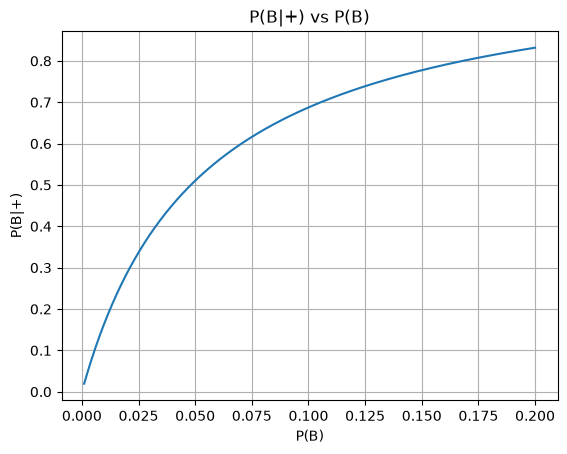

In [26]:
plt.plot(samples, plot_Bayes_B_given_pos(samples))
plt.title("P(B|+) vs P(B)")
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")    
plt.grid()
plt.show()

Khi bệnh hiếm có xác suất thấp như 0.1%, thế nhưng kết quả cho ra thực sự mắc bệnh nếu dương tính lại vô cùng thấp (xét nghiệm được xem là "nhạy"). Điều này xuất phát từ sự phản trực giác với mọi người rằng việc độ nhạy 99% của xét nghiệm chứng minh rằng có thể phát hiện được bệnh rất cao, nhưng nó chỉ nhạy khi người đó thực sự mắc bệnh, và để lại dương tính giả (không bệnh nhưng vẫn test ra dương tính)

Ví dụ với 100,000 người, thì có tổng cộng 100 người mắc bệnh này, trong đó có 99 người được chẩn đoán đúng, còn lại 999,900 người không mắc bệnh, có 49,995 người chẩn đoán sai là dương tính, vậy khi biết là dương tính, tỉ lệ họ thực sự bệnh là rất thấp (~0.2%)

Sự sai lệch về trực giác này xuất phát từ việc họ bỏ qua góc nhìn của xác suất 0.1% tỉ lệ mắc bệnh hiếm, và sự to lớn của không gian mẫu của những người không mắc bệnh, dẫn đến dương tính giả, đã áp đảo hoàn toàn so với số người thực sự dương tính và xét nghiệm đúng

## 3. (BONUS) Naive Bayes

Naive Bayes là định lý Bayes nhưng giả sử các features (từ khoá) xuất hiện độc lập, thì có ước lượng sau:

P(spam|email) = P(spam|keyword_1) * P(spam|keyword_2) * ... * P(spam|keyword_n) 

với các keywords này xuất hiện trong email

Ta thiết lập một vài xác suất cho sẵn, filter reject nếu tỉ lệ spam là cao (>75%)

In [27]:
P_spam = 0.5
P_keywords_prob_given_notspam = {'free': 0.5, 'money': 0.2, 'win': 0.01, 'click': 0.005} #P(keyword|_spam)
P_keywords_prob_given_spam = {'free': 0.9, 'money': 0.8, 'win': 0.7, 'click': 0.9} #P(keyword|spam)
def naive_bayes_spam_filter(keywords):
    naive_bayes = 1
    # tinh spam per keyword -> P(spam|keyword) = P(spam)*P(keyword)/P(keyword)
    for keyword in keywords:
        naive_bayes *= (P_keywords_prob_given_spam[keyword]*P_spam)/(P_keywords_prob_given_notspam[keyword]*(1-P_spam)+P_spam*P_keywords_prob_given_spam[keyword])
    if (naive_bayes>0.75):
        return ("Accepted",naive_bayes)
    return ("Rejected",naive_bayes)


In [28]:
print(naive_bayes_spam_filter(['money', 'free']))

('Rejected', 0.5142857142857143)


In [29]:
print(naive_bayes_spam_filter(['win', 'click']))

('Accepted', 0.980468446035328)


In [30]:
print(naive_bayes_spam_filter(['win','click','free','money']))

('Rejected', 0.504240915103883)
